In [30]:
!pip install xgboost -q

In [31]:
from sklearn.metrics import classification_report
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [32]:
# import the data set 
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [42]:

# split the data into X and Y
X = df.drop('species', axis=1)
y = df['species']

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # encode the X variables
# le = LabelEncoder()
# X= le.fit_transform(X)

# encode the target variable 
le = LabelEncoder()
y =le.fit_transform(y)

# train the decision tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# predict the test set
y_pred = dt.predict(X_test)



In [34]:


# print the metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('Confusion Matrix:\n', pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']))
print('Classification Report:\n', classification_report(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 Predicted   setosa  versicolor  virginica
Actual                                   
setosa          10           0          0
versicolor       0           9          0
virginica        0           0         11
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [35]:
%%time 
# train the random forest model 
rf =RandomForestClassifier()
rf.fit(X_train, y_train)

# predict the model 
y_pred = rf.predict(X_test)

print('accuracy_score: ', accuracy_score(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred, average='weighted'))
print('recall_Score:', recall_score(y_test, y_pred, average='weighted'))
print('f1_Score:', f1_score(y_test, y_pred, average='weighted'))

accuracy_score:  1.0
precision_score:  1.0
recall_Score: 1.0
f1_Score: 1.0
CPU times: total: 203 ms
Wall time: 203 ms


In [48]:

%%time
# encode the target variable 
le = LabelEncoder()
y_train =le.fit_transform(y_train)
y_test = le.fit_transform(y_test)
# train the XGBoost model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# predict the model 
y_pred = xgb.predict(X_test)

print('accuracy_score: ', accuracy_score(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred, average='weighted'))
print('recall_Score:', recall_score(y_test, y_pred, average='weighted'))
print('f1_Score:', f1_score(y_test, y_pred, average='weighted'))

accuracy_score:  1.0
precision_score:  1.0
recall_Score: 1.0
f1_Score: 1.0
CPU times: total: 391 ms
Wall time: 123 ms


Text(0.5, 1.0, 'XGboost _Tree_Classifier')

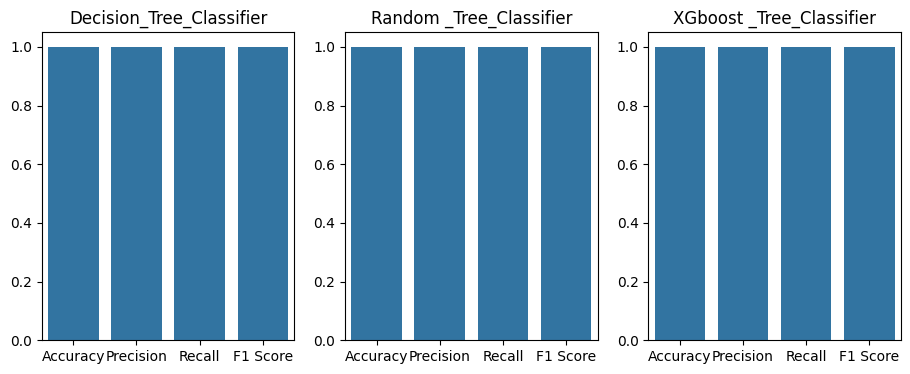

In [61]:
# make a bar plot showing each of matrix with respect to the model 
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1 Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')])
plt.title('Decision_Tree_Classifier')
plt.subplot(1,4,2)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1 Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')])
plt.title('Random _Tree_Classifier')

plt.subplot(1,4,3)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1 Score'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')])
plt.title('XGboost _Tree_Classifier')

